In [1]:
import importlib

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import model_functions
import utils

importlib.reload(model_functions)
importlib.reload(utils)

from model_functions import load_transition_matrix, gen_risk_matrix, gen_transition_probabilities, run_markov_cohort, \
    run_mc_sim, calculate_outcomes, plot_trace, load_costs, STAGE_ORDER, run_comparison

# Validation
Running validation checks on the baseline transition probabilities to determine which data source to use for our CEA model. Will run on the observation-based and trial-based probabilities (as well as the low/high CI values for each).

In [16]:
suffix_defs = ['trial'] #['obs', 'trial', 'obs_low', 'obs_high', 'trial_low', 'trial_high']

## Time to Severe Liver Disease/DC
Defines time for first 10% of patients to reach severe liver disease (cirrhosis/F4, liver decompensation/failure or hepatocellular carcinoma) from each starting fibrosis stage:
- F0 : 30.5 (21.5-39.6) years
- F1 : 35.6 (25.6-45.4) years
- F2 : 19.4 (9.3-29.5) years
- F3 : 6 (2.3-9.6) years

"Time to cirrhosis and consequently decompensation is based on a study in which a Laplace regression was used to estimate the time until the first 10% of patients had developed either cirrhosis, decompensation, hepatocellular carcinoma, or liver failure." (Hagstrom 2017)

The time until 10% of the patients had developed liver decompensation (DC):
- F0 : 33.4 (24.2–42.6)
- F1 : 34.1 (25.1–43.2)
- F2 : 22.7 (13.7–31.7)
- F3 : 11.8 (4.3–19.4)
- F4 : 5.6 (0.9–10.3)

Also: "Data from a simulation model using input mostly from biopsy-based studies found that the estimated 10-year liver-related mortality was 0·1% in patients with F0; 0·2% in those with F1; 1·0% in those with F2, 4·0% in those with F3; and 29·3% in those with F4." (Hagstrom 2017)

In [32]:
cohort_size = 500
cycle_len = 1
time_to_disease_results = []

for suf in suffix_defs:  # only do obs and trial for now
    liver_res = []
    dc_res = []
    mortality_res = []

    # '~/Documents/courses/HRP_392/final_baseline_transition_probs.csv'
    tm_stage_dc = load_transition_matrix('./final_baseline_transition_probs.csv', f"_{suf}",
                                     cycle_length=cycle_len)
    for starting_stage in range(5):
        init_prev = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        init_prev[starting_stage] = 1
        mc_trace = run_mc_sim(tm_stage_dc, init_prev, 63, cohort_size, starting_age=12,
                              cycle_length=cycle_len)
        
        if starting_stage != 4:
            first_hit = np.argmax(np.isin(mc_trace, [4, 5, 6]), axis=1)   # to severe liver disease
            first_hit[first_hit == 0] = 200
            liver_disease_stat = pd.Series(first_hit).quantile(0.1)
        else:
            liver_disease_stat = 0  # already in F4 at start
            
        first_hit = np.argmax(np.isin(mc_trace, [6]), axis=1)   # to DC
        first_hit[first_hit == 0] = 200
        dc_stat = pd.Series(first_hit).quantile(0.1)

        # mortality
        mortality_stat = (mc_trace.loc[:,22] == 9).sum().iloc[0] / cohort_size
        mortality_res.append(mortality_stat)
    
        liver_res.append(liver_disease_stat)
        dc_res.append(dc_stat)
        
    time_to_disease_df = pd.DataFrame({'severe_liver': liver_res, 'dc': dc_res, '10yr_mortality': mortality_res}).explode(['severe_liver', 'dc', '10yr_mortality'])
    time_to_disease_df['stage_init'] = ['F0', 'F1', 'F2', 'F3', 'F4']
    time_to_disease_df['suffix'] = suf
    time_to_disease_results.append(time_to_disease_df)

time_to_disease_results = pd.concat(time_to_disease_results, ignore_index=True)

In [33]:
# run with larger cohort on just trial
# Mortality inflated by all-cause mortality (not just liver-related) - but not too far off, especially for F4
time_to_disease_results

,severe_liver,dc,10yr_mortality,stage_init,suffix
0,18.9,35.0,0.006,F0,trial
1,11.0,30.0,0.010,F1,trial
2,6.0,26.9,0.032,F2,trial
3,2.0,14.9,0.082,F3,trial
4,0.0,2.0,0.314,F4,trial


In [170]:
time_to_disease_results

,severe_liver,dc,stage_init,suffix
0,42.9,59.0,F0,obs
1,22.9,200.0,F1,obs
2,12.0,33.9,F2,obs
3,3.0,14.8,F3,obs
4,0.0,2.0,F4,obs
5,18.0,30.0,F0,trial
6,10.0,33.9,F1,trial
7,6.0,19.9,F2,trial
8,2.0,14.0,F3,trial
9,0.0,2.0,F4,trial


In [171]:
with open('results/time_to_disease_results.pkl', 'wb') as f:
    pickle.dump(time_to_disease_results, f)

## ESSENCE Trial Liver Fibrosis Improvement
- Initial prevalance: 5/16 F2, 11/16 F3
- Placebo N=266, 22.4% had improvement in Liver Fibrosis (=59)
- Semaglutide N=534, 36.8% had improvement in Liver Fibrosis



In [4]:
essence_validation_results = []
n_iter = 100
for suf in suffix_defs:
    for i in range(n_iter):
        tm_mod = load_transition_matrix('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv', f"_{suf}",
                                        cycle_length=12 / 52.14)
        cohort_size = 266
        mc_trace = run_mc_sim(tm_mod, [0, 0, 5 / 16, 11 / 16, 0, 0, 0, 0, 0, 0], 6, cohort_size, starting_age=56,
                              cycle_length=12 / 52.14)
        
        # Number of patients with fibrosis regression after 72 weeks
        stage_changes = (mc_trace.iloc[:, -1] - mc_trace.iloc[:, 0]).value_counts().sort_index()
        regression_count = stage_changes[stage_changes.index < 0].sum()

        essence_validation_results.append([suf, i, regression_count])

essence_val_df = pd.DataFrame(essence_validation_results)

In [5]:
essence_val_df.to_csv('essence_validation_results.csv', index=False)

In [12]:
essence_val_df = pd.read_csv('results/essence_validation_results.csv', names=['source', 'iter', 'regression_count'], header=0)


In [13]:
essence_val_df.groupby('source')['regression_count'].describe()

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
obs,100.0,18.03,4.658987,9.0,15.00,18.0,21.25,29.0
obs_high,100.0,28.82,5.273107,19.0,25.00,28.0,32.00,44.0
obs_low,100.0,10.57,2.563359,5.0,9.00,11.0,12.00,16.0
trial,100.0,47.94,5.487948,33.0,44.75,48.5,51.00,64.0
trial_high,100.0,57.70,6.037760,43.0,53.00,57.0,62.00,74.0
trial_low,100.0,39.46,5.153051,29.0,36.00,40.0,43.00,54.0


In [7]:
# get 97.5th percentile for trial_low
essence_val_df[essence_val_df[0] == 'trial_low'][2].quantile(0.975)

np.float64(48.52499999999999)

In [8]:
essence_val_df[essence_val_df[0] == 'trial_low'][2].quantile(0.025)

np.float64(30.0)

With high confidence, the transition probabilities from trial (or maybe even trial_high) correspond best to the ESSENCE trial results.

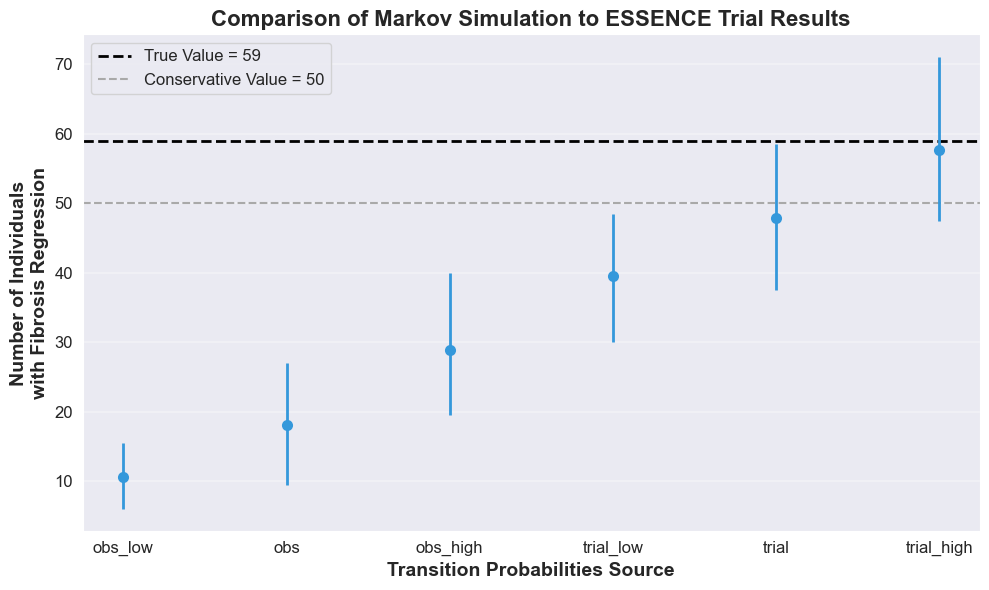

In [26]:
# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

grouped = essence_val_df.groupby('source')['regression_count'].agg([
    'mean',
    ('lower', lambda x: x.quantile(0.025)),
    ('upper', lambda x: x.quantile(0.975))
])
grouped = grouped.sort_values('mean')


# Calculate error bar sizes
grouped['err_low'] = grouped['mean'] - grouped['lower']
grouped['err_high'] = grouped['upper'] - grouped['mean']

# Plot
ax.errorbar(range(len(grouped)), grouped['mean'], 
            yerr=[grouped['err_low'], grouped['err_high']],
            fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2,
            color='#3498db', markeredgewidth=0)

# Add true value line
ax.axhline(y=59, color='black', linestyle='--', linewidth=2, 
           label='True Value = 59', zorder=1)
# Add true value line
ax.axhline(y=50, color='darkgray', linestyle='--', linewidth=1.5, 
           label='Conservative Value = 50', zorder=1)

# Formatting
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linewidth=1.5)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels(grouped.index, fontsize=12)
ax.set_ylabel('Number of Individuals\nwith Fibrosis Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Transition Probabilities Source', fontsize=14, fontweight='bold')
ax.set_title('Comparison of Markov Simulation to ESSENCE Trial Results', 
             fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig('essence_validation_plot.png', dpi=300)
plt.show()

## Newsome Trial Stage changes

- Initial Prevalance for Placebo group: 22 F1, 22 F2, 36 F3 (missing 5, 3, and 2 pts in final data)


In [44]:
comparison = pd.DataFrame([[5, 2, 1],
                           [6, 4, 7],
                           [4, 6, 6],
                           [2, 6, 18],
                           [0, 1, 2]], index=[0, 1, 2, 3, 4], columns=[1, 2, 3])
comparison_props = comparison / comparison.sum(axis=0)

In [ ]:
# TODO - should I make the initial prevalence match the trial exactly?

In [144]:
newsome_validation_results = {}
n_iter = 100
for suf in suffix_defs:
    newsome_validation_results[suf] = np.zeros((5,3), dtype=object)
    suf_counts = np.zeros((n_iter, 10, 3))
    for i in range(n_iter):
        tm_mod = load_transition_matrix('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv', f"_{suf}",
                                        cycle_length=12 / 52.14)
        cohort_size = 80
        mc_trace = run_mc_sim(tm_mod, [0, 22 / 80, 22 / 80, 36 / 80, 0, 0, 0, 0, 0, 0], 6, cohort_size, starting_age=55,
                              cycle_length=12 / 52.14)
        
        # Number of patients with fibrosis regression after 72 weeks
        stage_changes = (mc_trace.iloc[:, -1] - mc_trace.iloc[:, 0]).value_counts().sort_index()
        regression_count = stage_changes[stage_changes.index < 0].sum()
    
        counts = mc_trace.iloc[:, [0, -1]].value_counts().unstack().T.fillna(0)
        
        for j in range(10):
            if j not in counts.index:
                counts.loc[j, :] = [0, 0, 0]
        
        counts.sort_index(inplace=True)
        
        suf_counts[i,:,:] = counts
        
    suf_props = suf_counts / suf_counts.sum(axis=1, keepdims=True)
    
    for i in range(5):
        for j in range(3):
            lt = int((suf_props[:, i, j] < comparison_props.iloc[i, j]).sum())
            eq = int((suf_props[:, i, j] == comparison_props.iloc[i, j]).sum())
            gt = int((suf_props[:, i, j] > comparison_props.iloc[i, j]).sum())
            newsome_validation_results[suf][i, j] = (lt, eq, gt)



In [172]:
newsome_validation_results['trial']

array([[(99, 0, 1), (99, 0, 1), (98, 1, 1)],
       [(1, 0, 99), (69, 1, 30), (100, 0, 0)],
       [(73, 0, 27), (4, 1, 95), (62, 3, 35)],
       [(100, 0, 0), (90, 0, 10), (1, 0, 99)],
       [(0, 99, 1), (91, 2, 7), (28, 2, 70)]], dtype=object)

In [174]:
newsome_validation_results['trial_high']

array([[(95, 1, 4), (96, 1, 3), (98, 0, 2)],
       [(16, 1, 83), (61, 0, 39), (100, 0, 0)],
       [(28, 3, 69), (0, 1, 99), (54, 1, 45)],
       [(87, 1, 12), (92, 1, 7), (13, 0, 87)],
       [(0, 91, 9), (90, 2, 8), (9, 3, 88)]], dtype=object)

In [173]:
newsome_validation_results['obs']

array([[(100, 0, 0), (100, 0, 0), (100, 0, 0)],
       [(0, 0, 100), (98, 0, 2), (100, 0, 0)],
       [(100, 0, 0), (0, 0, 100), (98, 0, 2)],
       [(100, 0, 0), (100, 0, 0), (0, 0, 100)],
       [(0, 100, 0), (99, 0, 1), (58, 3, 39)]], dtype=object)

In [175]:
newsome_validation_results['obs_high']

array([[(100, 0, 0), (100, 0, 0), (99, 0, 1)],
       [(0, 0, 100), (98, 1, 1), (100, 0, 0)],
       [(98, 0, 2), (0, 0, 100), (88, 0, 12)],
       [(100, 0, 0), (100, 0, 0), (0, 0, 100)],
       [(0, 99, 1), (99, 0, 1), (57, 3, 40)]], dtype=object)

In [176]:
import pickle
with open('results/newsome_validation_results.pkl', 'wb') as f:
    pickle.dump(newsome_validation_results, f)

## Liver Transplant rates

In [ ]:
# Use total population, multiply by proportion of transplants